<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 125 · Case Study: From Model to Decision</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: From Model to Decision</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">The discipline that turns a trained model into a trustworthy decision: catching a data leak that fakes a perfect score, comparing models without being fooled by noise, choosing the metric that matches the question (where accuracy actively misleads), setting the threshold by cost, and communicating the result. Library-first with scikit-learn, and heavily visual.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# From Model to Decision: evaluating and communicating a model
The earlier case studies each built a model. This one is about everything *around* the model, the judgement that turns a trained classifier into a trustworthy business decision. Using an employee-attrition problem, we will catch a **data leak** that makes a model look perfect, **compare models** without being fooled by noise, choose the **right metric** for the question (accuracy will actively mislead us), turn the score into a **decision** with a cost matrix, and **communicate** it. The lessons here apply to every model in the book. Library-first with `scikit-learn`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score, recall_score,
     precision_score, roc_curve)
import warnings; warnings.filterwarnings('ignore'); pd.set_option('display.max_columns', 40)

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 1 &#183; DEFINE THE OBJECTIVE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A decision, not a score</div>
<div style="color:#4a5578;margin-top:6px">The model exists to drive an action.</div>
</div>

**The real goal.** An HR team wants to reduce **attrition** by offering retention support to employees at risk of leaving. The model's job is not to be 'accurate', it is to help decide **who to talk to**, given that losing an employee is expensive and a retention conversation is cheap. Keeping that decision in view is what makes every downstream choice, metric, threshold, model, correct or wrong.

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">STEP 2 &#183; COLLECT THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">An HR export</div>
<div style="color:#4a5578;margin-top:6px">One row per employee.</div>
</div>

In [3]:
try: df = pd.read_csv('../../data/employee_attrition.csv')
except FileNotFoundError: df = pd.read_csv(BASE + 'employee_attrition.csv')
df = df.drop_duplicates('employee_id')
print('shape:', df.shape, '| attrition rate: %.1f%%' % (df.attrition.mean()*100)); df.head(3)

shape: (4000, 13) | attrition rate: 18.6%


,employee_id,age,tenure_years,monthly_salary,satisfaction,work_life_balance,overtime,num_promotions,years_since_promotion,commute_km,job_role,exit_process_started,attrition
0,E71694,35,4.2,7833,2.0,3,No,1,1.7,13,Engineering,1,1
1,E71189,21,1.0,4379,5.0,4,No,1,3.0,2,Support,0,0
2,E70091,37,5.7,9831,4.0,2,No,1,4.3,25,Sales,0,0


**A moderately rare target.** About **19%** of employees left, so a model that predicts 'stays' for everyone is already **81% accurate**, our first warning that accuracy will be a poor guide. The columns are the usual HR signals, satisfaction, work-life balance, salary, overtime, promotions, commute, plus one that deserves suspicion.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 3 &#183; INSPECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One column looks too good</div>
<div style="color:#4a5578;margin-top:6px">Spot the leak before it fools you.</div>
</div>

In [4]:
print('correlation of each feature with attrition:')
num = df.select_dtypes('number').drop(columns=['attrition'])
print(num.corrwith(df.attrition).abs().sort_values(ascending=False).round(3).to_string())
print('\nattrition rate by exit_process_started:')
print(df.groupby('exit_process_started').attrition.mean().round(3).to_string())

correlation of each feature with attrition:
exit_process_started     0.918
satisfaction             0.260
work_life_balance        0.177
commute_km               0.062
years_since_promotion    0.060
monthly_salary           0.048
tenure_years             0.045
num_promotions           0.029
age                      0.006

attrition rate by exit_process_started:
exit_process_started
0    0.013
1    0.923


**A predictor that is almost the answer.** `exit_process_started` correlates far more strongly with attrition than any real signal, employees for whom it is 1 leave over 90% of the time. That is the classic fingerprint of a **leak**: the offboarding process is only started *after* someone has already resigned. At scoring time, for a current employee, it is always 0. Using it would build a model that is useless in practice but looks spectacular in testing.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 4 &#183; CLEAN</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Minimal, and honest</div>
<div style="color:#4a5578;margin-top:6px">Set the features, exclude the leak.</div>
</div>

In [5]:
numeric = ['age','tenure_years','monthly_salary','satisfaction','work_life_balance','num_promotions','years_since_promotion','commute_km']
categorical = ['overtime','job_role']
# exit_process_started is DELIBERATELY excluded: it is a post-outcome leak
preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)])
print('features used:', len(numeric)+len(categorical), '(exit_process_started left out on purpose)')

features used: 10 (exit_process_started left out on purpose)


<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 5 &#183; PROVE THE LEAK</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Too good to be true, quantified</div>
<div style="color:#4a5578;margin-top:6px">What the leak does to the score.</div>
</div>

WITH the leaky feature:  ROC-AUC 0.987  <- looks amazing, and is a lie
honest model (no leak):  ROC-AUC 0.756  <- what you would actually get in production


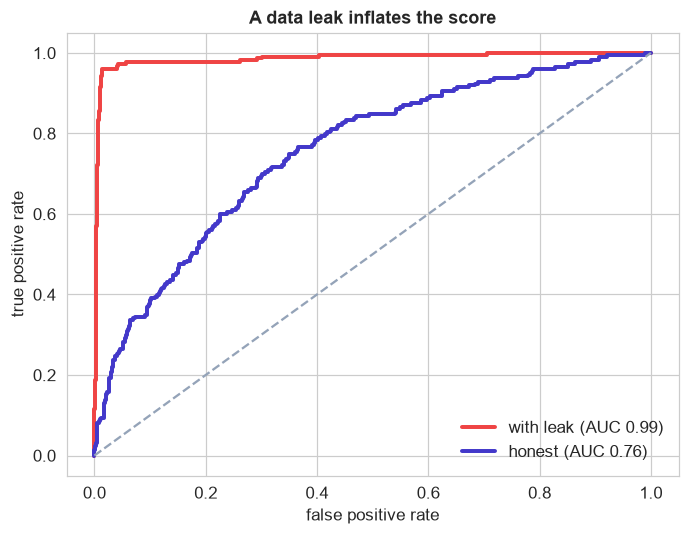

In [6]:
y = df['attrition']
X_leaky = df[numeric+['exit_process_started']+categorical]; X_honest = df[numeric+categorical]
Xl_tr,Xl_te,yl_tr,yl_te = train_test_split(X_leaky, y, test_size=0.3, random_state=0, stratify=y)
Xh_tr,Xh_te,yh_tr,yh_te = train_test_split(X_honest, y, test_size=0.3, random_state=0, stratify=y)
pre_leaky = ColumnTransformer([('num', Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler())]), numeric+['exit_process_started']), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)])
leaky = Pipeline([('p',pre_leaky),('c',LogisticRegression(max_iter=2000,class_weight='balanced'))]).fit(Xl_tr,yl_tr)
honest = Pipeline([('p',preprocess),('c',LogisticRegression(max_iter=2000,class_weight='balanced'))]).fit(Xh_tr,yh_tr)
auc_leaky = roc_auc_score(yl_te, leaky.predict_proba(Xl_te)[:,1]); auc_honest = roc_auc_score(yh_te, honest.predict_proba(Xh_te)[:,1])
print('WITH the leaky feature:  ROC-AUC %.3f  <- looks amazing, and is a lie' % auc_leaky)
print('honest model (no leak):  ROC-AUC %.3f  <- what you would actually get in production' % auc_honest)
fig, ax = plt.subplots(figsize=(6.4,5))
for m,X,yt,lab,c in [(leaky,Xl_te,yl_te,'with leak',RED),(honest,Xh_te,yh_te,'honest',EM)]:
    fpr,tpr,_ = roc_curve(yt, m.predict_proba(X)[:,1]); ax.plot(fpr,tpr,color=c,lw=2.6,label=f'{lab} (AUC {roc_auc_score(yt,m.predict_proba(X)[:,1]):.2f})')
ax.plot([0,1],[0,1],'--',color=GREY); ax.set(title='A data leak inflates the score', xlabel='false positive rate', ylabel='true positive rate'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

**Leakage is the most dangerous evaluation mistake.** Including `exit_process_started` rockets the AUC to **0.99**, a model that would collapse to **0.76** the moment it met a real, current employee. The tell was the too-good score, and the fix was understanding *when* each feature becomes known. Before trusting any high number, ask: could this feature have been recorded only after the outcome? We proceed with the **honest** feature set.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 6 &#183; COMPARE MODELS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Is a 0.02 gap real, or noise?</div>
<div style="color:#4a5578;margin-top:6px">Cross-validate, and look fold by fold.</div>
</div>

Logistic             CV ROC-AUC 0.747 +/- 0.014


Random Forest        CV ROC-AUC 0.711 +/- 0.012


Gradient Boosting    CV ROC-AUC 0.723 +/- 0.017

Logistic minus Gradient Boosting, per fold: [0.03  0.023 0.014 0.02  0.03 ]
logistic wins in all 5 folds: True -> the edge is consistent, not a lucky split


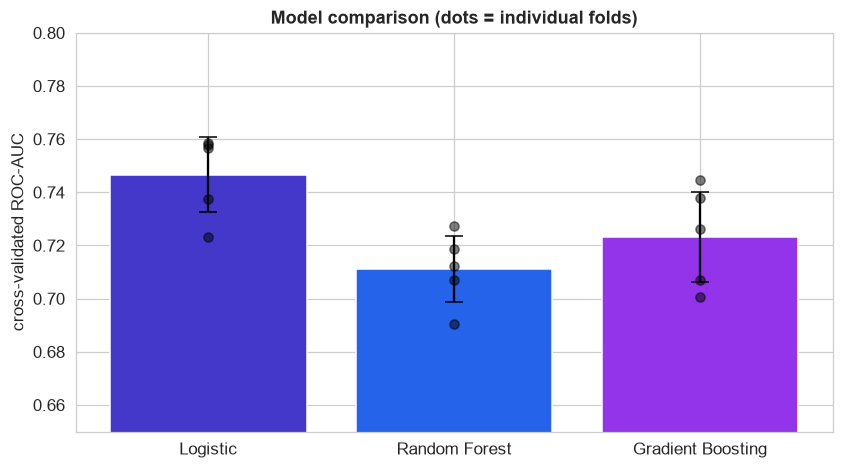

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_honest, y, test_size=0.3, random_state=0, stratify=y)
cv = StratifiedKFold(5, shuffle=True, random_state=0); scores = {}
for name, clf in [('Logistic', LogisticRegression(max_iter=2000, class_weight='balanced')),
                  ('Random Forest', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=0)),
                  ('Gradient Boosting', GradientBoostingClassifier(random_state=0))]:
    s = cross_val_score(Pipeline([('p',preprocess),('c',clf)]), X_train, y_train, cv=cv, scoring='roc_auc')
    scores[name] = s; print(f'{name:20s} CV ROC-AUC {s.mean():.3f} +/- {s.std():.3f}')
diff = scores['Logistic'] - scores['Gradient Boosting']
print(f'\nLogistic minus Gradient Boosting, per fold: {np.round(diff,3)}')
print(f'logistic wins in all 5 folds: {bool((diff>0).all())} -> the edge is consistent, not a lucky split')
fig, ax = plt.subplots(figsize=(7.8,4.4))
means=[s.mean() for s in scores.values()]; stds=[s.std() for s in scores.values()]
ax.bar(scores.keys(), means, yerr=stds, capsize=6, color=[EM,BLUE,PUR])
for i,s in enumerate(scores.values()): ax.plot([i]*len(s), s, 'o', color='k', alpha=0.5)
ax.set(ylabel='cross-validated ROC-AUC', title='Model comparison (dots = individual folds)', ylim=(0.65,0.8)); plt.tight_layout(); plt.show()

**Do not over-read a single split.** The three models land within a few points of each other, close enough that on one lucky train/test split any of them could look best. The disciplined check is **cross-validation, examined fold by fold**: logistic regression beats gradient boosting in **all five folds** (mean edge about 0.02), so its advantage is real and consistent, not noise, and it is the simpler, more interpretable model. That combination makes it the clear choice. Had the per-fold differences flipped signs, we would have called it a tie and picked the simpler model anyway.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 7 &#183; THE RIGHT METRIC</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Accuracy will betray you here</div>
<div style="color:#4a5578;margin-top:6px">The metric must match the decision.</div>
</div>

In [8]:
model = Pipeline([('p',preprocess),('c',LogisticRegression(max_iter=2000, class_weight='balanced'))]).fit(X_train, y_train)
prob = model.predict_proba(X_test)[:,1]; yv = y_test.values
do_nothing = np.zeros_like(yv)
pred_05 = (prob>=0.5).astype(int)
print('predict everyone STAYS: accuracy %.3f, but recall %.3f (catches ZERO leavers)' % (accuracy_score(yv,do_nothing), recall_score(yv,do_nothing)))
print('the model at 0.5:       accuracy %.3f, recall %.3f' % (accuracy_score(yv,pred_05), recall_score(yv,pred_05)))
print('\naccuracy actually RANKS do-nothing above the model, yet do-nothing helps no one.')
print('ROC-AUC %.3f | PR-AUC %.3f  <- these reward ranking leavers correctly' % (roc_auc_score(yv,prob), average_precision_score(yv,prob)))

predict everyone STAYS: accuracy 0.814, but recall 0.000 (catches ZERO leavers)
the model at 0.5:       accuracy 0.705, recall 0.664

accuracy actually RANKS do-nothing above the model, yet do-nothing helps no one.
ROC-AUC 0.756 | PR-AUC 0.441  <- these reward ranking leavers correctly


**Accuracy is the wrong yardstick.** Because only 19% leave, predicting 'stays' for everyone scores **81% accuracy**, higher than our working model, while identifying **not a single at-risk employee**. If we optimized accuracy we would ship the do-nothing model and help nobody. The metric has to reflect the goal: we care about **catching leavers** (recall) and **ranking** them (ROC-AUC, PR-AUC), and ultimately about the **dollar value** of the decision, which comes next.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 8 &#183; FROM SCORE TO DECISION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Put a cost on each mistake</div>
<div style="color:#4a5578;margin-top:6px">The threshold is where value is made.</div>
</div>

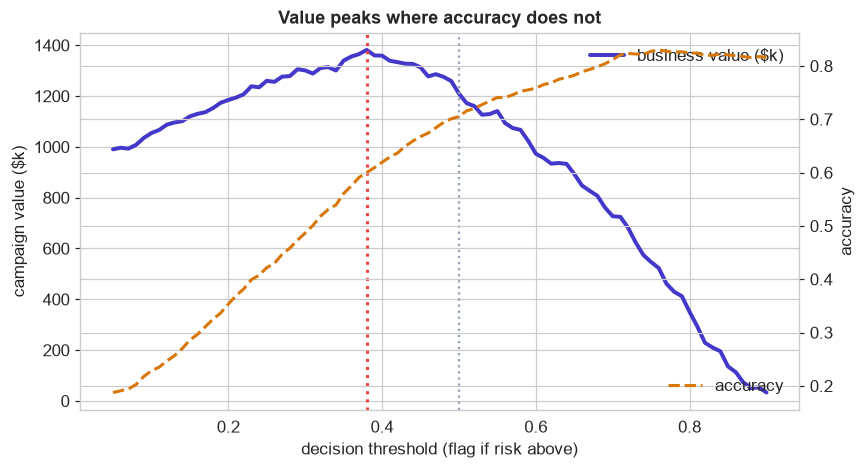

threshold 0.50: accuracy 0.70 | recall 0.66 | value $1,209,500
threshold 0.38: accuracy 0.60 | recall 0.83 | value $1,381,500


In [9]:
COST_LOSS = 25000     # cost to replace an employee who leaves
COST_OUTREACH = 1500  # cost of a retention conversation / incentive
SAVE_RATE = 0.5       # a retention effort keeps ~half of the would-be leavers
ths = np.linspace(0.05, 0.9, 86); value = []; acc = []
for t in ths:
    flag = prob >= t
    caught_leavers = (flag & (yv==1)).sum()
    value.append(caught_leavers*SAVE_RATE*COST_LOSS - flag.sum()*COST_OUTREACH)
    acc.append(accuracy_score(yv, flag.astype(int)))
best_t = ths[int(np.argmax(value))]
fig, ax = plt.subplots(figsize=(8,4.4)); ax2 = ax.twinx()
ax.plot(ths, np.array(value)/1000, color=EM, lw=2.6, label='business value ($k)')
ax2.plot(ths, acc, color=AMBER, lw=2.0, ls='--', label='accuracy')
ax.axvline(best_t, color=RED, ls=':', lw=2); ax.axvline(0.5, color=GREY, ls=':')
ax.set(xlabel='decision threshold (flag if risk above)', ylabel='campaign value ($k)', title='Value peaks where accuracy does not')
ax2.set_ylabel('accuracy'); ax.legend(loc='upper right'); ax2.legend(loc='lower right')
plt.tight_layout(); plt.show()
for t in [0.5, best_t]:
    f=(prob>=t).astype(int); v=(f&(yv==1)).sum()*SAVE_RATE*COST_LOSS - f.sum()*COST_OUTREACH
    print('threshold %.2f: accuracy %.2f | recall %.2f | value $%s' % (t, accuracy_score(yv,f), recall_score(yv,f), f'{v:,.0f}'))

**Accuracy and value point in opposite directions.** With a departure costing far more than a conversation, the **value curve peaks around a threshold of 0.38**, well below 0.5, catching most at-risk employees. But look at the dashed accuracy line: it *falls* exactly where value rises, the profit-maximizing decision is one of the least 'accurate' operating points, and the most 'accurate' choice (flag no one) creates zero value. The lesson of the chapter in one picture: **choose the threshold by the decision's economics, and never by accuracy.**

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 9 &#183; INTERPRET</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What actually drives leaving</div>
<div style="color:#4a5578;margin-top:6px">Turn the model into insight.</div>
</div>

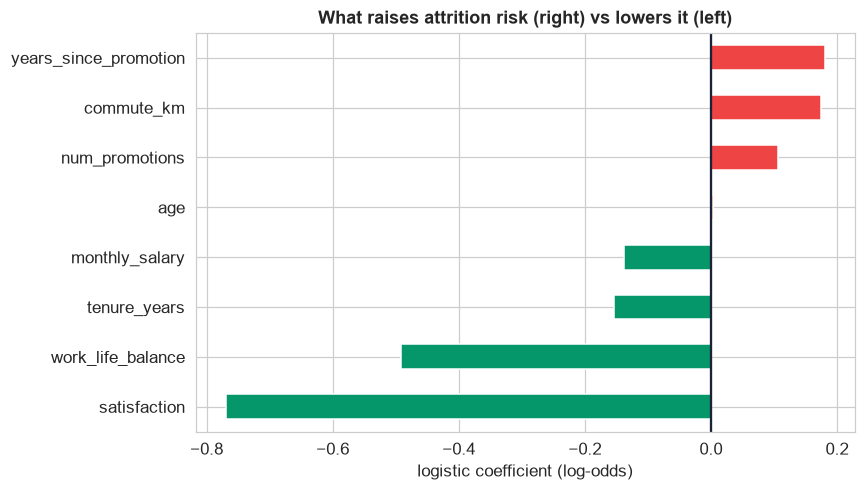

strongest drivers (by magnitude): satisfaction, work_life_balance, years_since_promotion, commute_km


In [10]:
coefs = pd.Series(model.named_steps['c'].coef_[0][:len(numeric)], index=numeric).sort_values()
fig, ax = plt.subplots(figsize=(8,4.6))
coefs.plot.barh(ax=ax, color=[RED if c>0 else GREEN for c in coefs.values]); ax.axvline(0, color=INK)
ax.set(title='What raises attrition risk (right) vs lowers it (left)', xlabel='logistic coefficient (log-odds)')
plt.tight_layout(); plt.show()
print('strongest drivers (by magnitude):', ', '.join(coefs.abs().sort_values(ascending=False).head(4).index))

**Insight, not just a score.** Low **satisfaction** and poor **work-life balance** are the strongest departure signals, followed by a long time **since the last promotion**, a long **commute**, and **overtime**, while higher **salary** and **tenure** hold people. This is arguably more valuable to HR than the predictions themselves: it points at levers, career progression, workload, flexibility, that reduce attrition at the source, not just a list of who to chase.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 10 &#183; COMMUNICATE + DEPLOY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One paragraph for the decision-makers</div>
<div style="color:#4a5578;margin-top:6px">Score a new employee, state the action.</div>
</div>

In [11]:
import joblib; joblib.dump(model, 'attrition_model.joblib'); svc = joblib.load('attrition_model.joblib')
new = pd.DataFrame([
  {'age':29,'tenure_years':1.5,'monthly_salary':4200,'satisfaction':2,'work_life_balance':1,'num_promotions':0,'years_since_promotion':3.0,'commute_km':45,'overtime':'Yes','job_role':'Support'},
  {'age':45,'tenure_years':12,'monthly_salary':11000,'satisfaction':5,'work_life_balance':4,'num_promotions':4,'years_since_promotion':1.0,'commute_km':8,'overtime':'No','job_role':'Engineering'}])
for j in range(len(new)):
    p = svc.predict_proba(new.iloc[[j]])[0,1]
    action = 'FLAG for a retention conversation' if p >= best_t else 'no action'
    print(f'employee {j+1}: attrition risk {p:.0%}  ->  {action}')
print('\nSTAKEHOLDER SUMMARY: the model flags the roughly one-in-six employees most at risk of leaving,')
print('so HR can focus retention effort where it pays. It is right often enough to be worth acting on,')
print('the drivers point to satisfaction, workload, and career progress, and a control group will confirm the impact.')

employee 1: attrition risk 88%  ->  FLAG for a retention conversation
employee 2: attrition risk 5%  ->  no action

STAKEHOLDER SUMMARY: the model flags the roughly one-in-six employees most at risk of leaving,
so HR can focus retention effort where it pays. It is right often enough to be worth acting on,
the drivers point to satisfaction, workload, and career progress, and a control group will confirm the impact.


**Close the loop in plain language.** The saved model scores a new employee, the unhappy, overworked junior with a long commute is flagged; the well-paid, satisfied, recently-promoted senior is not, and the decision comes with a one-paragraph summary a manager can act on: what it does, how good it is, what drives it, and what to do. That translation, from probabilities to a sentence a decision-maker trusts, is the final and most under-rated step of any modeling project.

## From model to decision, in one view

1. **Hunt for leakage first**: a feature known only after the outcome (here `exit_process_started`) inflated AUC from an honest 0.76 to a fake 0.99.
2. **Compare models fold by fold**: logistic beat the ensembles in all five CV folds, a consistent, real edge, and it is simpler.
3. **Pick the metric that matches the decision**: accuracy ranked 'do nothing' first while catching zero leavers; recall, PR-AUC, and value are the right lenses.
4. **Set the threshold by economics**: business value peaked near 0.38, exactly where accuracy was worst.
5. **Interpret and communicate**: the drivers point to real levers, and a one-paragraph summary turns the model into a decision people will act on.

**A model is not a decision. The value is created in how you evaluate it, threshold it, and explain it.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>